In [35]:
!pip install torchmetrics
import torch
from torch import nn

import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

torchvision.__version__

'0.24.0+cu126'

In [36]:
import torchvision.transforms as transforms

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2023, 0.1994, 0.2010)
    )
])
train_data = datasets.CIFAR10(
    root = "data",
    train = True,
    download = True,
    transform=train_transform,
    target_transform=None,

)

test_data = datasets.CIFAR10(
    root = "data",
    train = False,
    download = True,
    transform=ToTensor(),

)
from torch.utils.data import DataLoader
train_loader = DataLoader(
    train_data,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_data,
    batch_size=32,
    shuffle=False
)

In [37]:
class_names = train_data.classes
class_names

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

In [38]:
import torchvision.transforms.functional as F
image=train_data[0][0]
print(F.get_image_num_channels(image))

3


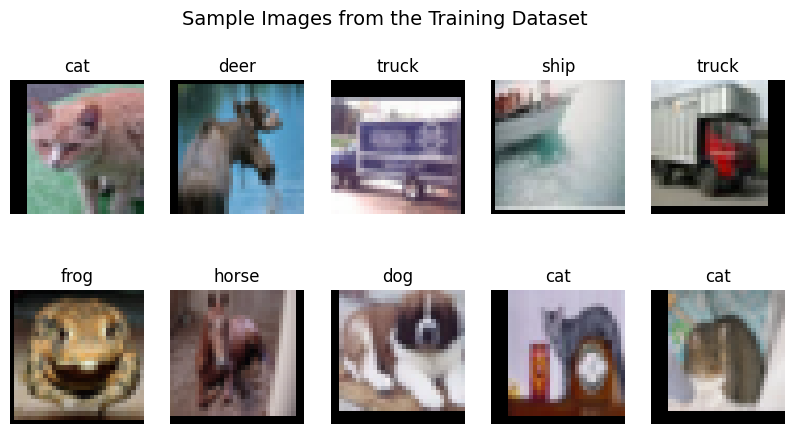

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# get a batch
images, labels = next(iter(train_loader))  # images: tensor (B, C, H, W)
mean = np.array([0.4914, 0.4822, 0.4465])
std  = np.array([0.2023, 0.1994, 0.2010])

def unnormalize_tensor(img_tensor, mean=mean, std=std):
    # img_tensor is torch tensor shape (C, H, W)
    img = img_tensor.permute(1, 2, 0).cpu().numpy()   # -> (H, W, C)
    img = img * std + mean                            # broadcast per channel
    img = np.clip(img, 0.0, 1.0)
    return img

plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(unnormalize_tensor(images[i]))
    plt.title(class_names[labels[i]])
    plt.axis('off')

plt.suptitle("Sample Images from the Training Dataset", fontsize=14)
plt.show()

In [40]:
from torch import nn
class CIFAR(nn.Module):
  def __init__(self):
    super().__init__()
    self.stack_layers=nn.Sequential(
    # First convolution
    nn.Conv2d(3, 25, kernel_size=3, stride=1, padding=1),
    nn.BatchNorm2d(25),
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),  # 25 x 14 x 14
    # Second convolution
    nn.Conv2d(25, 50, kernel_size=3, stride=1, padding=1),  # 50 x 14 x 14
    nn.BatchNorm2d(50),
    nn.ReLU(),
    nn.Dropout(.2),
    nn.MaxPool2d(2, stride=2),  # 50 x 7 x 7
    # Third convolution
    nn.Conv2d(50, 75, kernel_size=3, stride=1, padding=1),  # 75 x 7 x 7
    nn.BatchNorm2d(75),
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),  # 75 x 3 x 3
    # Flatten to Dense
    nn.Flatten(),
    nn.Linear(in_features=1200, out_features=512),
    nn.Dropout(.3),
    nn.ReLU(),
    nn.Linear(512, 10)
)
  def forward(self , x):
   return self.stack_layers(x)


In [41]:
torch.manual_seed(42)

model_0 = CIFAR()


In [42]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model_0.to(device)

CIFAR(
  (stack_layers): Sequential(
    (0): Conv2d(3, 25, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(25, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(25, 50, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(50, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(50, 75, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): BatchNorm2d(75, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU()
    (12): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (13): Flatten(start_dim=1, end_dim=-1)
    (14): Linear(in_features=1200, out_features=512, bias=True)
    (15): Dropout(p=0.3

In [43]:
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.SGD(params=model_0.parameters(),lr=0.1)

In [44]:
epochs=15
for epoch in range(epochs):
    print(f"Epoch: {epoch}\n----------")
    model_0.train()  # set model to training mode
    total_loss = 0  # track loss for this epoch
    for X, y in train_loader:
      # Move data to the same device as the model (CPU or GPU)
        X = X.to(device)
        y = y.to(device)

        # Forward pass: get model predictions
        outputs = model_0(X)
        loss = loss_fn(outputs, y)

        # Backward pass and optimization step
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Accumulate loss for logging
        total_loss += loss.item()

    # Average loss over all batches in this epoch
    avg_loss = total_loss / len(train_loader)

    print(f"Epoch {epoch + 1}/{epochs} | Training Loss: {avg_loss:.4f}")

Epoch: 0
----------
Epoch 1/15 | Training Loss: 1.5935
Epoch: 1
----------
Epoch 2/15 | Training Loss: 1.2112
Epoch: 2
----------
Epoch 3/15 | Training Loss: 1.0288
Epoch: 3
----------
Epoch 4/15 | Training Loss: 0.9278
Epoch: 4
----------
Epoch 5/15 | Training Loss: 0.8647
Epoch: 5
----------
Epoch 6/15 | Training Loss: 0.8114
Epoch: 6
----------
Epoch 7/15 | Training Loss: 0.7747
Epoch: 7
----------
Epoch 8/15 | Training Loss: 0.7420
Epoch: 8
----------
Epoch 9/15 | Training Loss: 0.7133
Epoch: 9
----------
Epoch 10/15 | Training Loss: 0.6963
Epoch: 10
----------
Epoch 11/15 | Training Loss: 0.6773
Epoch: 11
----------
Epoch 12/15 | Training Loss: 0.6533
Epoch: 12
----------
Epoch 13/15 | Training Loss: 0.6356
Epoch: 13
----------
Epoch 14/15 | Training Loss: 0.6220
Epoch: 14
----------
Epoch 15/15 | Training Loss: 0.6089


In [45]:
from torchmetrics import Precision, Recall
metric_precision = Precision(task="multiclass", num_classes=10, average='macro').to(device)
metric_recall = Recall(task="multiclass", num_classes=10, average='macro').to(device)

model_0.eval()
with torch.no_grad():
  for X, y in test_loader:
    X = X.to(device)
    y = y.to(device)
    outputs = model_0(X)
    metric_precision(outputs, y)
    metric_recall(outputs, y)
  print(f"Precision: {metric_precision.compute()}")
  print(f"Recall: {metric_recall.compute()}")

Precision: 0.2726280689239502
Recall: 0.17350000143051147


In [46]:
def simple_visualize(model, loader, device, n=6, classes=class_names, mean=mean, std=std):
    model.eval()
    images, labels = next(iter(loader))   # images: (B, C, H, W)
    images = images.to(device)
    images_cpu = images.cpu()
    labels_cpu = labels.cpu()

    with torch.no_grad():
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu()

    plt.figure(figsize=(12, 4))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        img_np = unnormalize_tensor(images_cpu[i], mean=mean, std=std)
        plt.imshow(img_np)
        plt.title(f"P: {classes[preds[i]]}\nT: {classes[labels_cpu[i]]}")
        plt.axis("off")
    plt.show()

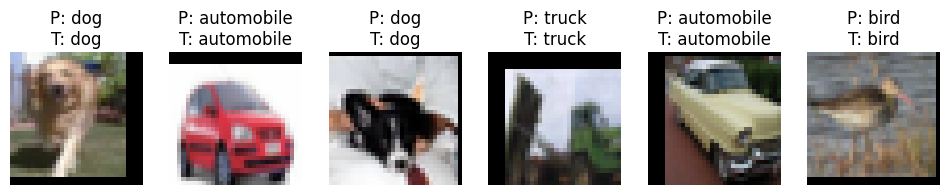

In [47]:
simple_visualize(model_0, train_loader, device, n=6)

In [48]:
torch.save(model_0.state_dict(), "model_0.pth")